In [ ]:
# Employee Attrition Rate
 """  Objective : This project focuses on Employee Attrition Analysis to understand why employees leave a company ,
      so the goal is to identify key factors affecting attrition."""


In [ ]:
 # Install & import libraries

!pip install -q hvplot

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

sns.set_style("whitegrid")
plt.style.use("fivethirtyeight")

In [ ]:
#  Load dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
 # get  Basic info
 df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
 #  Check unique values
 for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

Age: 43 unique values
Attrition: 2 unique values
BusinessTravel: 3 unique values
DailyRate: 886 unique values
Department: 3 unique values
DistanceFromHome: 29 unique values
Education: 5 unique values
EducationField: 6 unique values
EmployeeCount: 1 unique values
EmployeeNumber: 1470 unique values
EnvironmentSatisfaction: 4 unique values
Gender: 2 unique values
HourlyRate: 71 unique values
JobInvolvement: 4 unique values
JobLevel: 5 unique values
JobRole: 9 unique values
JobSatisfaction: 4 unique values
MaritalStatus: 3 unique values
MonthlyIncome: 1349 unique values
MonthlyRate: 1427 unique values
NumCompaniesWorked: 10 unique values
Over18: 1 unique values
OverTime: 2 unique values
PercentSalaryHike: 15 unique values
PerformanceRating: 2 unique values
RelationshipSatisfaction: 4 unique values
StandardHours: 1 unique values
StockOptionLevel: 4 unique values
TotalWorkingYears: 40 unique values
TrainingTimesLastYear: 7 unique values
WorkLifeBalance: 4 unique values
YearsAtCompany: 37 uni

In [ ]:
# Drop Useless columns
df.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], axis=1, inplace=True)

In [ ]:
 # Check missing values
 df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


/tmp/ipykernel_9248/1458461429.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Attrition', data=df, palette=['#4CAF50','#F44336'])


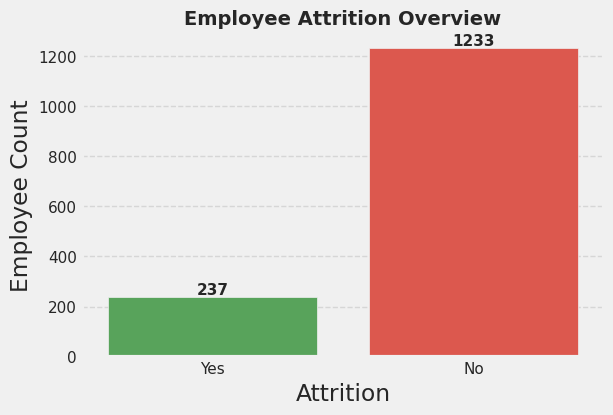

In [ ]:
# Total Attrition Count
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Attrition', data=df, palette=['#4CAF50','#F44336'])

plt.title("Employee Attrition Overview", fontsize=14, weight='bold')
plt.xlabel("Attrition")
plt.ylabel("Employee Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold')

plt.show()

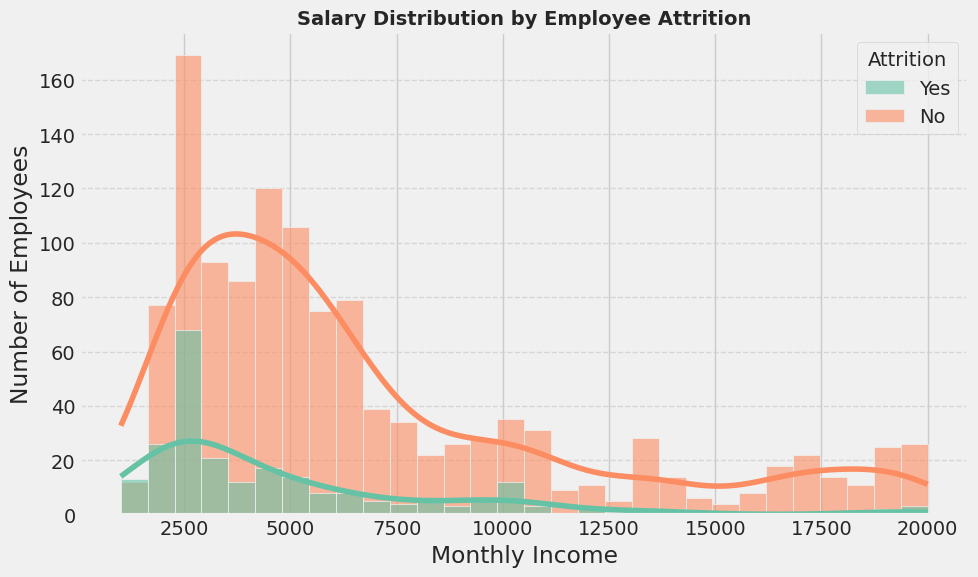

In [ ]:
# Attrition by Monthly Income
# Purpose : To analyze the relationship between salary and employee attrition.

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='MonthlyIncome',
    hue='Attrition',
    kde=True,
    bins=30,
    palette='Set2',
    alpha=0.6
)

plt.title("Salary Distribution by Employee Attrition", fontsize=14, weight='bold')
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

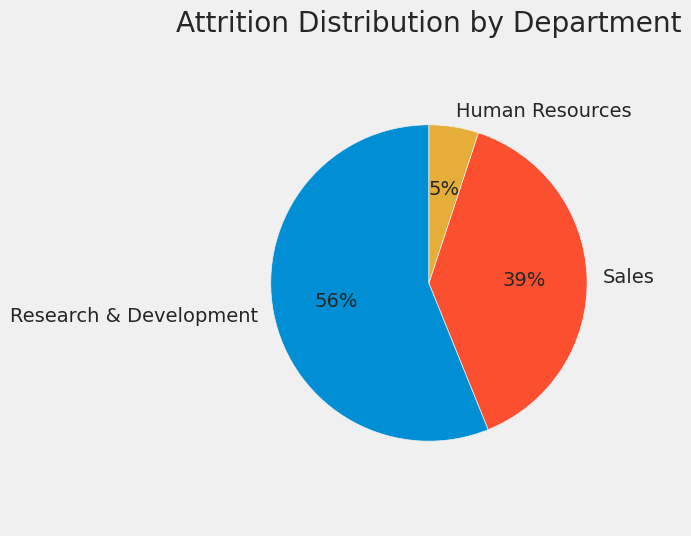

In [ ]:
# Attrition by Department
 # Purpose : Check which department has high attrition rate
import matplotlib.pyplot as plt

# Filter only employees who left
attrition_yes = df[df['Attrition'] == 'Yes']

# Count by department
dept_counts = attrition_yes['Department'].value_counts()

# Plot pie chart
plt.figure(figsize=(4,6))

plt.pie(dept_counts,
        labels=dept_counts.index,
        autopct='%1.0f%%',
        startangle=90)

plt.title("Attrition Distribution by Department")
plt.axis('equal')  # Makes pie circular

plt.show()

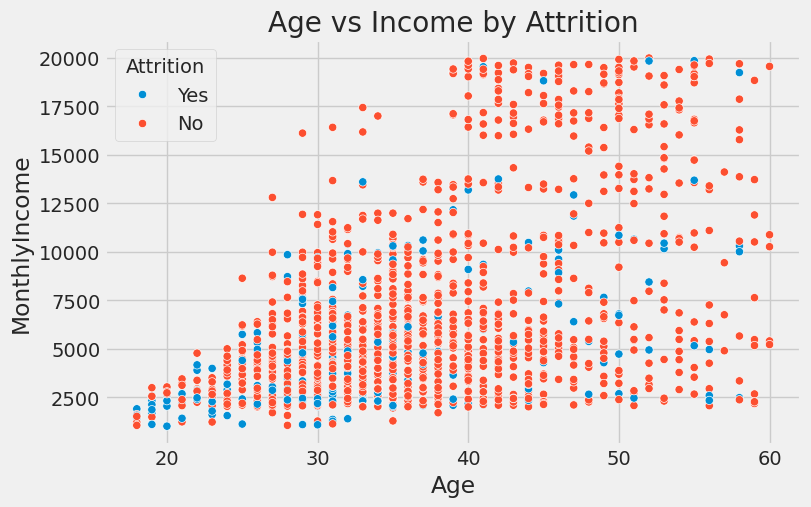

In [ ]:
# Age vs Income by Attrition
# purpose :To study how age and income together impact employee attrition.”

plt.figure(figsize=(8,5))

sns.scatterplot(x='Age', y='MonthlyIncome', hue='Attrition', data=df)

plt.title("Age vs Income by Attrition")
plt.show()

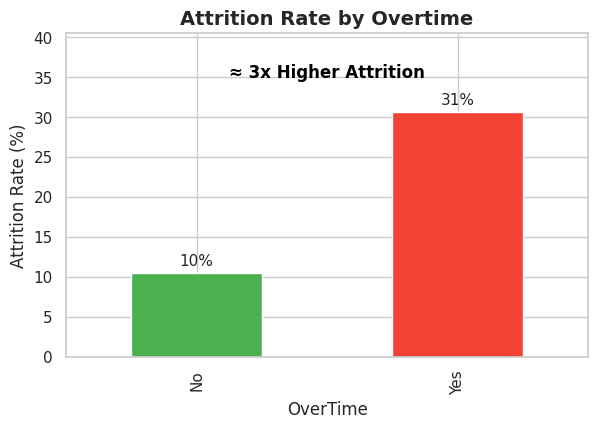

In [ ]:
# Attrition by Overtime
# Purpose :Check if overtime causes attrition

sns.set(style="whitegrid")

attrition_overtime = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
ax = attrition_overtime['Yes'].plot(kind='bar', figsize=(6,4), color=['#4CAF50', '#F44336'])

# Labels
plt.title("Attrition Rate by Overtime", fontsize=14, weight='bold')
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")

for i, v in enumerate(attrition_overtime['Yes']):
    ax.text(i, v + 1, f"{v:.0f}%", ha='center', fontsize=11)

plt.ylim(0, attrition_overtime['Yes'].max() + 10)
plt.text(0.5, 35, "≈ 3x Higher Attrition",
         ha='center', fontsize=12, color='black', weight='bold')
plt.show()

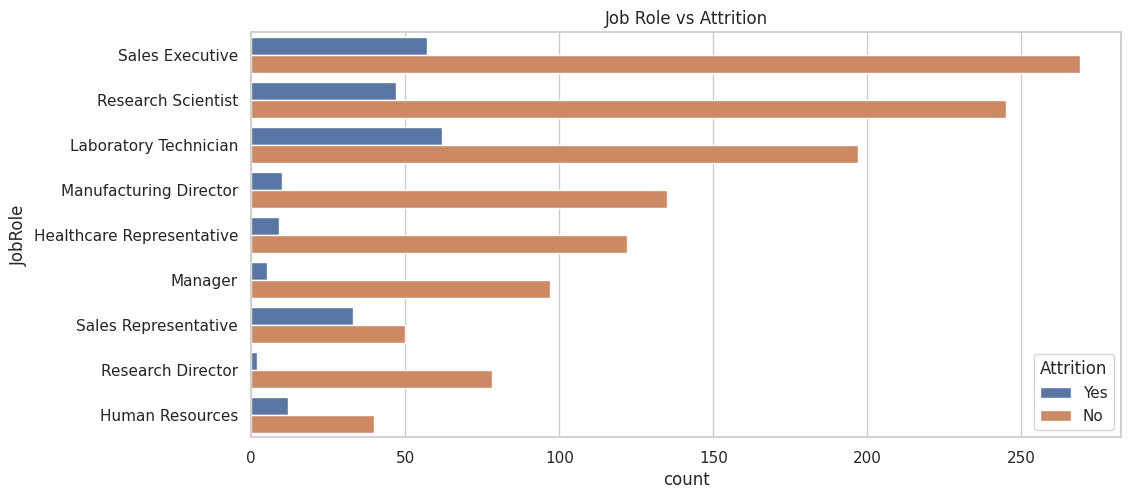

In [ ]:
# Attrition by Job Role
# Purpose:Identify which roles have high attrition

plt.figure(figsize=(10,5))
sns.countplot(y='JobRole', hue='Attrition', data=df)
plt.title("Job Role vs Attrition")
plt.show()

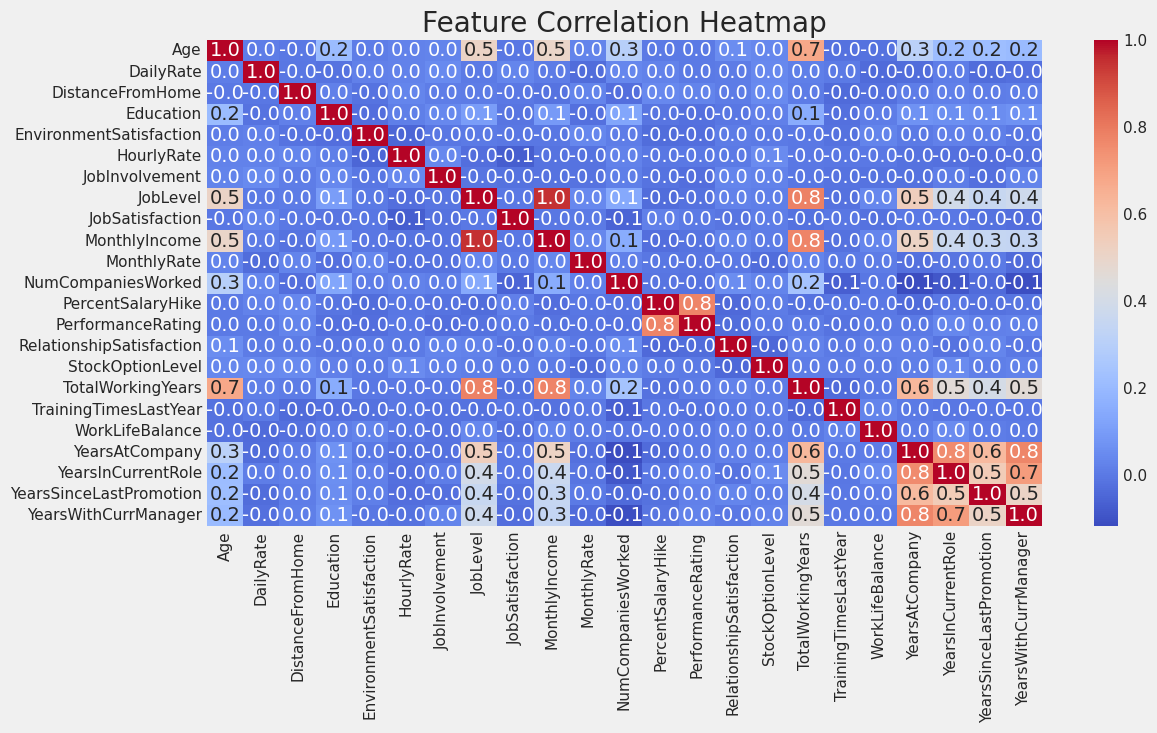

In [ ]:
# Feature Correlation Heatmap
#Purpose:  To visualize and understand correlations between numerical variables in the dataset.

plt.figure(figsize=(12,6))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.1f')

plt.title("Feature Correlation Heatmap")
plt.show()